In [2]:
# import zone
import pandas as pd

df02_user = pd.read_csv('charangData/user.csv',encoding='cp949')
df07_booking = pd.read_csv('charangData/booking.csv',encoding='cp949')
df07_car = pd.read_csv('charangData/car.csv',encoding='cp949')

### 2. **월별 가입자수 추이**
#### - **그래프유형**: 꺾은선 그래프
#### - **기대효과**: 월별 가입차 추이를 통해 유입이 저조한 달의 경우, 대책 기획
#### - **X축**: 월(Month)
#### - **Y축**: 가입자수(Count)
#### - **Raw Data**: user

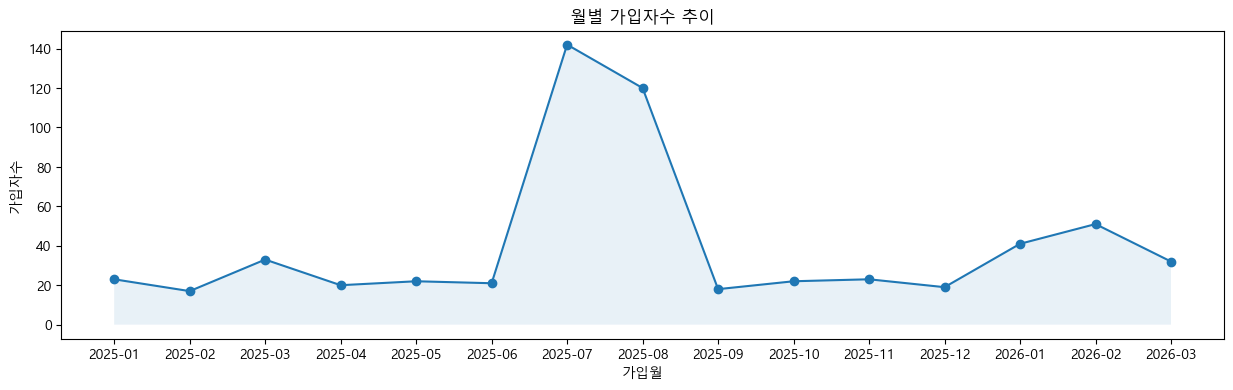

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 결측치 확인
# print(df02.isna().sum())

df02_user['regDate'] = pd.to_datetime(df02_user['regDate'])
df02_user[['name', 'regDate']]

result = df02_user.groupby(df02_user['regDate'].dt.to_period('M')).size().reset_index(name='가입자수')
result['regDate'] = result['regDate'].astype(str) # period타입을 문자열로 변환

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(15,4))

# 03. 꺽은선 그래프
plt.plot(result['regDate'],result['가입자수'],marker='o')

# 04. 영역 추가
plt.fill_between(result['regDate'],result['가입자수'],alpha=0.1)

# 05. 제목, 라벨 지정
plt.title('월별 가입자수 추이')
plt.xlabel('가입월')
plt.ylabel('가입자수')

plt.show()




### .7 **차종별(연료타입분리x) 예약 횟수**
#### - **그래프유형**: 막대사탕 차트
#### - **기대효과**: 인기 차량 확인가능. 들여올 차량 선정시 유효
#### - **X축**: 수(Count)
#### - **Raw Data**: booking / car

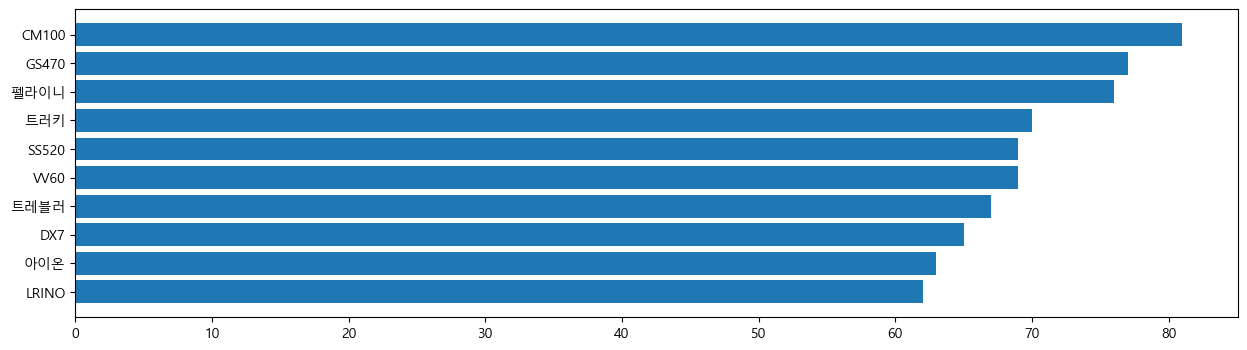

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

merge07 = pd.merge(df07_booking,df07_car,how='outer',on='carId')
result = merge07.groupby('model').size().sort_values(ascending=False).head(10).sort_values(ascending=True).reset_index(name='예약건수')

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 02. 그래프 크기 설정
plt.figure(figsize=(15,4))

# 03. 막대그래프
plt.barh(result['model'],result['예약건수'],height=0.8)

# 04. 
plt.show()